# SMARD power market data

Download German electricity market data published by the Bundesnetzagentur and
save it as CSV. API docs: <https://smard.api.bund.dev/> — no API key required.

Run top to bottom: **settings** → **check endpoints** → **download** → **save CSV**.

Requires: `pandas`

## 1. Settings

Everything you would normally change lives in this cell.

In [10]:
from datetime import datetime, timezone
from zoneinfo import ZoneInfo

import pandas as pd
import requests

BASE = "https://www.smard.de/app"
LOCAL_TZ = ZoneInfo("Europe/Berlin")   # timestamps are converted to this zone

# Series to download. To add one, append a line: <id>: "<name>",
# Further IDs are listed in the API docs under "filter".
FILTERS = {
    1225: "Wind Offshore",
    4067: "Wind Onshore",
    4068: "Solar",
    410:  "Grid Load",
    4359: "Residual Load",
    5097: "Forecast Wind + Solar",
}

REGION     = "DE"
RESOLUTION = "hour"                            # "hour" or "quarterhour"
START      = datetime(2022, 1, 1, tzinfo=LOCAL_TZ)   # inclusive
END        = datetime(2026, 9, 8, tzinfo=LOCAL_TZ)   # exclusive
CSV_FILE   = "../data/smard.csv"

print(f"{len(FILTERS)} series | {RESOLUTION} | "
      f"{START:%Y-%m-%d} to {END:%Y-%m-%d}")

6 series | hour | 2022-01-01 to 2026-09-08


## 2. Functions

`fetch()` does the actual work. The API has no free date-range query, it only
serves whole **weekly packages**:

1. call the index endpoint → list of all available package timestamps
2. download only the packages that overlap the requested range
3. trim to the exact start/end yourself

Note that filter and region appear twice in the second URL (`filter`/`filterCopy`,
`region`/`regionCopy`) — that is how the API is built.

In [11]:
def to_ms(dt):
    """datetime -> milliseconds since epoch (the format the API expects)."""
    return int(dt.timestamp() * 1000)


def to_local(t):
    """Milliseconds since epoch -> datetime in LOCAL_TZ."""
    return datetime.fromtimestamp(t / 1000, tz=timezone.utc).astimezone(LOCAL_TZ)


def index_url(filter_id, resolution=None, region=None):
    resolution = resolution or RESOLUTION
    region = region or REGION
    return f"{BASE}/chart_data/{filter_id}/{region}/index_{resolution}.json"


def fetch(filter_id, start=None, end=None, resolution=None, region=None, session=None):
    """Return all values of one series between start and end as a dict."""
    start = start or START
    end = end or END
    resolution = resolution or RESOLUTION
    region = region or REGION
    a, b = to_ms(start), to_ms(end)

    http = session or requests            # reuse the connection if given
    index = sorted(http.get(index_url(filter_id, resolution, region),
                            timeout=30).json()["timestamps"])

    wanted = [p for i, p in enumerate(index)
              if p < b and (i + 1 == len(index) or index[i + 1] > a)]

    values = {}
    for n, package in enumerate(wanted, 1):
        url = (f"{BASE}/chart_data/{filter_id}/{region}"
               f"/{filter_id}_{region}_{resolution}_{package}.json")
        for t, value in http.get(url, timeout=30).json()["series"]:
            if a <= t < b:
                values[to_local(t)] = value
        if n % 50 == 0 or n == len(wanted):
            print(f"    {n}/{len(wanted)} packages", end="\r")
    return values


def check_endpoints(resolution=None, region=None):
    """Ping every filter's index endpoint. Returns True if all responded."""
    all_ok = True
    for filter_id, name in FILTERS.items():
        try:
            response = requests.get(index_url(filter_id, resolution, region), timeout=15)
            status = "ok" if response.status_code == 200 else f"HTTP {response.status_code}"
        except Exception as error:
            status = type(error).__name__
        if status != "ok":
            all_ok = False
        print(f"  {filter_id:>5}  {name:<24} {status}")
    return all_ok

## 3. Check endpoints

Calls each index endpoint once. Anything other than `ok` means either the filter
ID is wrong or the service is currently unreachable.

In [12]:
ok = check_endpoints()
print("\nAll endpoints reachable." if ok
      else "\nWarning: at least one endpoint did not respond.")

   1225  Wind Offshore            ok
   4067  Wind Onshore             ok
   4068  Solar                    ok
    410  Grid Load                ok
   4359  Residual Load            ok
   5097  Forecast Wind + Solar    ok

All endpoints reachable.


## 4. Download

Takes seconds to a few minutes depending on range and resolution
(`quarterhour` is 672 values per week and series instead of 168).

In [13]:
data = {}
with requests.Session() as s:
    for filter_id, name in FILTERS.items():
        data[name] = fetch(filter_id, session=s)
        print(f"{name:<24} {len(data[name]):>7} values")

df = pd.DataFrame(data)
df.index.name = "timestamp"
df = df.sort_index()

print(f"\n{df.shape[0]} timestamps x {df.shape[1]} series")

Wind Offshore              41059 values
Wind Onshore               41059 values
Solar                      41059 values
Grid Load                  41059 values
Residual Load              41059 values
Forecast Wind + Solar      41059 values

41059 timestamps x 6 series


In [14]:
df.head(12)

,Wind Offshore,Wind Onshore,Solar,Grid Load,Residual Load,Forecast Wind + Solar
timestamp,,,,,,
2022-01-01 00:00:00+01:00,5975.50,25570.25,2.0,43915.50,12367.75,31530.75
2022-01-01 01:00:00+01:00,5775.25,24318.25,2.0,41535.75,11440.25,30462.50
2022-01-01 02:00:00+01:00,5548.00,23169.50,2.0,40480.75,11761.25,29055.25
2022-01-01 03:00:00+01:00,5382.75,22092.50,2.0,39564.00,12086.75,27607.50
2022-01-01 04:00:00+01:00,5586.50,20607.00,2.0,39338.25,13142.75,26255.50
2022-01-01 05:00:00+01:00,4531.25,19575.25,2.0,38826.50,14718.00,24841.50
2022-01-01 06:00:00+01:00,4514.75,19274.50,2.0,38413.00,14621.75,23725.75
2022-01-01 07:00:00+01:00,4850.00,18045.50,2.0,39076.25,16178.75,22336.50
2022-01-01 08:00:00+01:00,4172.00,16691.75,224.0,40299.25,19211.50,21178.25


## 5. Quick look

Optional sanity check. `NaN` means the API returned `null` for that timestamp.

In [15]:
display(df.describe().T[["count", "mean", "min", "max"]])
print("missing values per series:")
print(df.isna().sum())

,count,mean,min,max
Wind Offshore,41059.0,2902.763846,0.00,8448.34
Wind Onshore,41059.0,12438.844824,46.50,48499.50
Solar,41059.0,7745.571710,0.00,58055.53
Grid Load,41059.0,53335.426424,30902.75,78680.50
Residual Load,41059.0,30248.246068,-15561.59,70964.00
Forecast Wind + Solar,41059.0,22966.552270,320.50,75722.20


missing values per series:
Wind Offshore            0
Wind Onshore             0
Solar                    0
Grid Load                0
Residual Load            0
Forecast Wind + Solar    0
dtype: int64


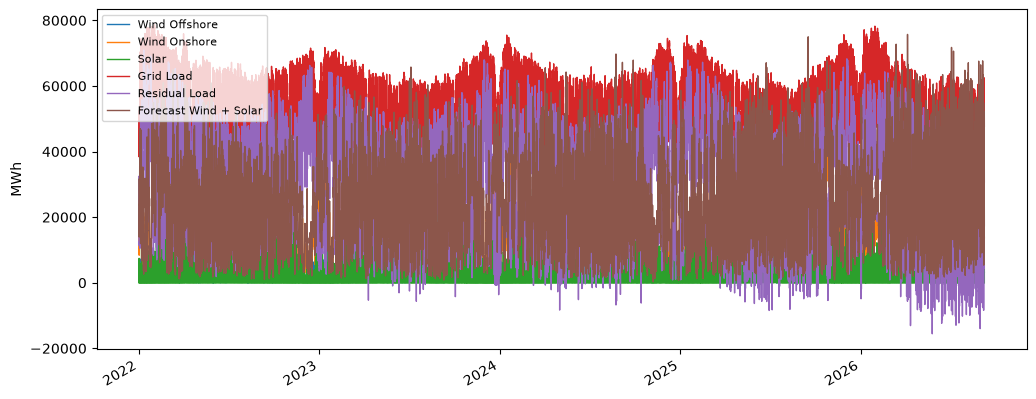

In [16]:
ax = df.plot(figsize=(12, 5), linewidth=1)
ax.set_ylabel("MWh")
ax.set_xlabel("")
ax.legend(loc="upper left", fontsize=8)

## 6. Save as CSV

The timestamp is written as `YYYY-MM-DD HH:MM` without a UTC offset such as
`+02:00`, which Excel cannot parse. Times are local (`LOCAL_TZ`).

The default matches **German Excel**: semicolon separator, comma as decimal mark.
Use the second line for a standard CSV.

In [17]:
export = df.copy()
export.index = export.index.strftime("%Y-%m-%d %H:%M")

# German Excel
export.to_csv(CSV_FILE, sep=";", decimal=",", encoding="utf-8-sig")

# standard CSV (comma separator, dot as decimal mark)
# export.to_csv(CSV_FILE, encoding="utf-8")

print(f"saved: {CSV_FILE}\n")
with open(CSV_FILE, encoding="utf-8-sig") as f:
    for _ in range(3):
        print(f.readline().strip())

saved: ../data/smard.csv

timestamp;Wind Offshore;Wind Onshore;Solar;Grid Load;Residual Load;Forecast Wind + Solar
2022-01-01 00:00;5975,5;25570,25;2,0;43915,5;12367,75;31530,75
2022-01-01 01:00;5775,25;24318,25;2,0;41535,75;11440,25;30462,5


---

### Fetching a single series

If you need one series or a different range without touching the settings above:

```python
s = pd.Series(fetch(4068, datetime(2026, 8, 1, tzinfo=LOCAL_TZ),
                          datetime(2026, 8, 8, tzinfo=LOCAL_TZ)))
```